In [1]:
import sklearn
from sklearn.datasets import fetch_openml
 
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame


In [2]:
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)

In [3]:
print("\ndataset info:")
df.info()


dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [4]:
 print(df.isna().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


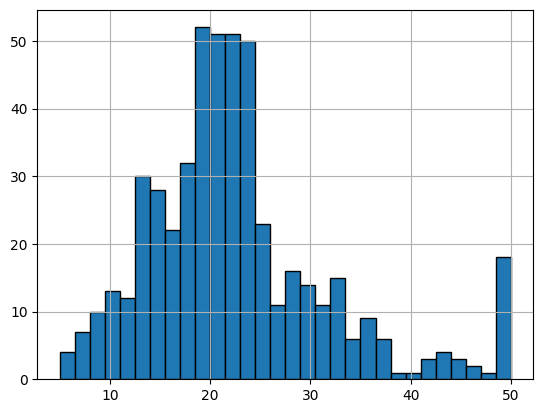

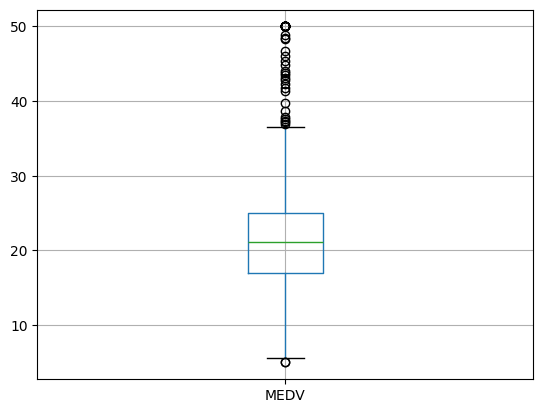

In [5]:
import matplotlib.pyplot as plt

df['MEDV'].hist(bins=30, edgecolor='black')
plt.show()

df.boxplot(column='MEDV')
plt.show()


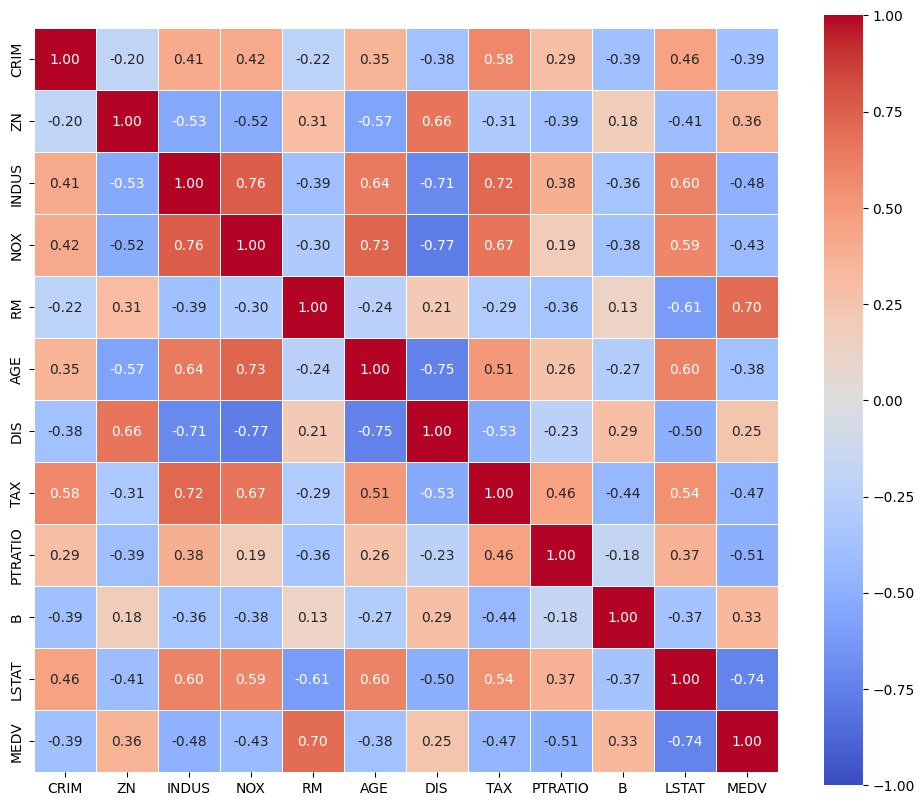

In [6]:
import seaborn as sns
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr, 
    annot=True,         
    fmt=".2f",          
    cmap="coolwarm",    
    vmin=-1, vmax=1,     
    linewidths=0.5,      
    square=True        
)

plt.show()   #признаки с наибольшей корреляцией с MEDV - RM, LSTAT

In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=666
)

train_df = train_df.copy()
test_df = test_df.copy()

print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (404, 14)
Test: (102, 14)


In [8]:
train_df['is_high_value'] = (train_df['MEDV'] > 30).astype(int)
test_df['is_high_value'] = (test_df['MEDV'] > 30).astype(int)

print(train_df[train_df['is_high_value'] == 1][['MEDV', 'is_high_value']])

     MEDV  is_high_value
97   38.7              1
306  33.4              1
275  32.0              1
181  36.2              1
253  42.8              1
..    ...            ...
282  46.0              1
276  33.2              1
204  50.0              1
225  50.0              1
223  30.1              1

[67 rows x 2 columns]


In [9]:
from scipy import stats
import numpy as np

cols_to_scale = [
    'CRIM', 'ZN', 'INDUS', 'NOX', 'RM',
    'AGE', 'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

z_scores = np.abs(stats.zscore(train_df[cols_to_scale]))

train_df_cleaned = train_df[
    (z_scores < 3).all(axis=1)
].copy()

print("Rows before:", len(train_df))
print("Rows after:", len(train_df_cleaned))
print("Rows deleted:", len(train_df) - len(train_df_cleaned))

Rows before: 404
Rows after: 357
Rows deleted: 47


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(train_df_cleaned[cols_to_scale])

train_df_cleaned[cols_to_scale] = scaler.transform(
    train_df_cleaned[cols_to_scale]
)

test_df[cols_to_scale] = scaler.transform(
    test_df[cols_to_scale]
)

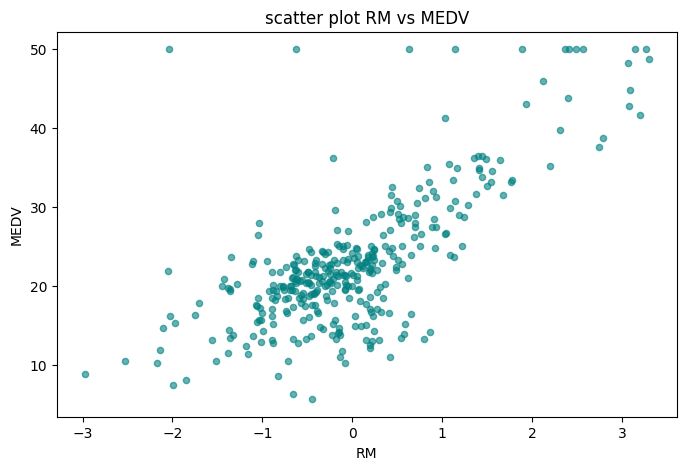

In [11]:
train_df_cleaned.plot.scatter(x='RM', y='MEDV', alpha=0.6, color='teal', figsize=(8, 5))
plt.title('scatter plot RM vs MEDV')
plt.show()

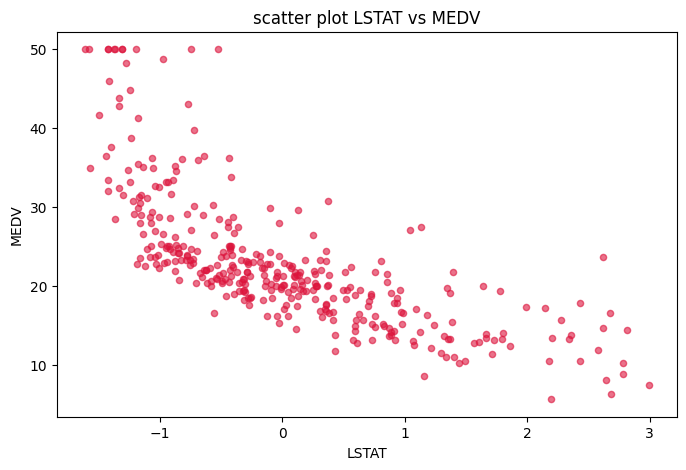

In [12]:
train_df_cleaned.plot.scatter(x='LSTAT', y='MEDV', alpha=0.6, color='crimson', figsize=(8, 5))
plt.title('scatter plot LSTAT vs MEDV')
plt.show()

In [13]:
from sklearn.linear_model import LinearRegression
import numpy as np

features = ['RM', 'LSTAT', 'PTRATIO']

X_train = train_df_cleaned[features].copy()
y_train = train_df_cleaned['MEDV'].copy()

X_test = test_df[features].copy()
y_test = test_df['MEDV'].copy()

model = LinearRegression()
model.fit(X_train, y_train)

print("coeffs:")
print(f"Intercept: {model.intercept_:.3f}")

for feature, coef in zip(features, model.coef_):
    print(f"{feature}: {coef:.3f}")

#интерпретация: свободный коэф 22.918 — прогноз для объекта с средними значениями всех трех признаков.

coeffs:
Intercept: 22.918
RM: 3.643
LSTAT: -3.481
PTRATIO: -1.680


In [14]:

y_train_pred = (
    X_train['RM'].to_numpy() * model.coef_[0]
    + X_train['LSTAT'].to_numpy() * model.coef_[1]
    + X_train['PTRATIO'].to_numpy() * model.coef_[2]
    + model.intercept_
)

y_test_pred = (
    X_test['RM'].to_numpy() * model.coef_[0]
    + X_test['LSTAT'].to_numpy() * model.coef_[1]
    + X_test['PTRATIO'].to_numpy() * model.coef_[2]
    + model.intercept_
)

In [15]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import pandas as pd

# train
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = root_mean_squared_error(y_train, y_train_pred)

# test
test_r2 = r2_score(y_test, y_test_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = root_mean_squared_error(y_test, y_test_pred)

metrics_df = pd.DataFrame({
    'Metric': ['R²', 'MAE', 'RMSE'],
    'Train': [train_r2, train_mae, train_rmse],
    'Test': [test_r2, test_mae, test_rmse]
})

print(metrics_df.round(3))

#R^2 Модель объясняет около 58.8% вариации целевой переменной на тестовой выборке.

  Metric  Train   Test
0     R²  0.692  0.588
1    MAE  3.261  3.793
2   RMSE  4.768  5.528


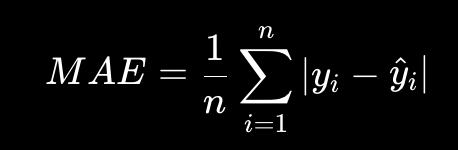

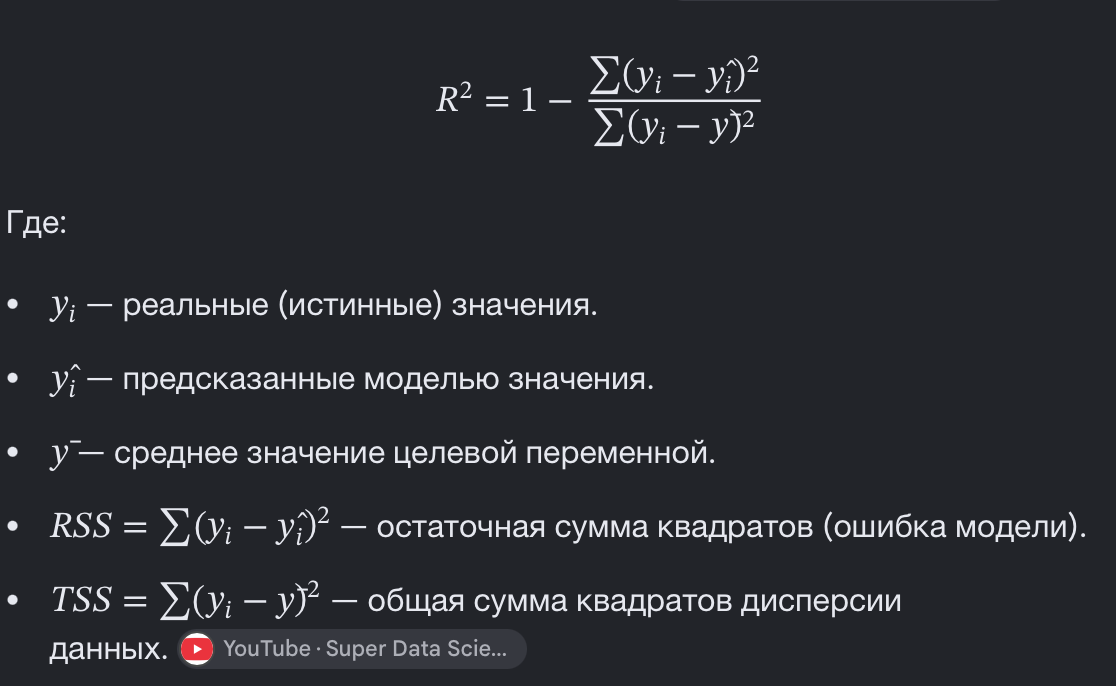

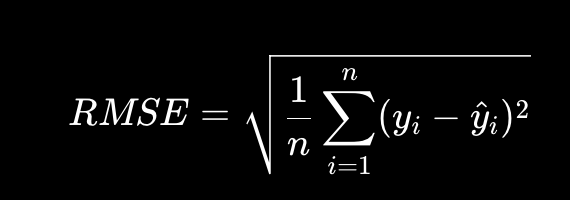

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = train_df_cleaned[['RM', 'LSTAT', 'PTRATIO']].copy()

vif_df = pd.DataFrame()

vif_df['Feature'] = X_vif.columns
vif_df['VIF'] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df.round(3))

# VIF < 5. Между тремя выбранными признаками нет особой мультиколлинеарности
# В случае высокой мультиколлинеарности матрица X^TX стала бы близка к вырожденной
# Обратной матрицы для нее бы не существовало
# Если определитель близок к нулю, но не равен 0, то решение становится чсленно неустойчивым
# Небольшое изменение входных данных может приводить к значительному изменению отдельных коэффициентов

   Feature    VIF
0       RM  1.668
1    LSTAT  1.665
2  PTRATIO  1.121


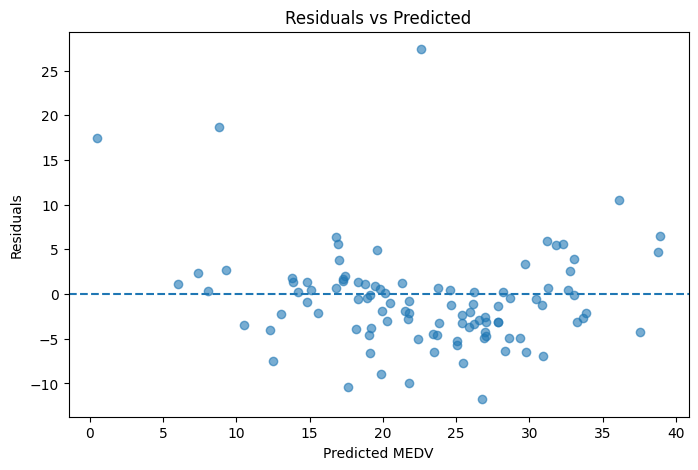

In [17]:
import matplotlib.pyplot as plt
import numpy as np

residuals = y_test.to_numpy() - y_test_pred

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted MEDV')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')

plt.show()

#Есть выбросы, гомоскедастичность не идеальная. Есть зависимость остатков от предсказанных значений

In [18]:
class MatrixLinearRegression:

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)

        X_with_bias = np.insert(X, 0, 1, axis=1)

        # w = (X^T X)^(-1) X^T y
        XT_X_inv = np.linalg.inv(X_with_bias.T @ X_with_bias)
        weights = np.linalg.multi_dot([
            XT_X_inv,
            X_with_bias.T,
            y
        ])

        self.bias = weights[0]
        self.weights = weights[1:]

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=np.float64)

        return X @ self.weights + self.bias

In [19]:
matrix_lr = MatrixLinearRegression()

matrix_lr.fit(X_train, y_train)

matrix_train_pred = matrix_lr.predict(X_train)
matrix_test_pred = matrix_lr.predict(X_test)

In [20]:
print("Matrix Linear Regression")
print(f"Intercept: {matrix_lr.bias:.3f}")

for feature, weight in zip(features, matrix_lr.weights):
    print(f"{feature}: {weight:.3f}")

#results are similar

Matrix Linear Regression
Intercept: 22.918
RM: 3.643
LSTAT: -3.481
PTRATIO: -1.680


In [21]:
cluster_features = ['CRIM', 'NOX', 'DIS']

X_cluster = train_df_cleaned[cluster_features].copy()

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)


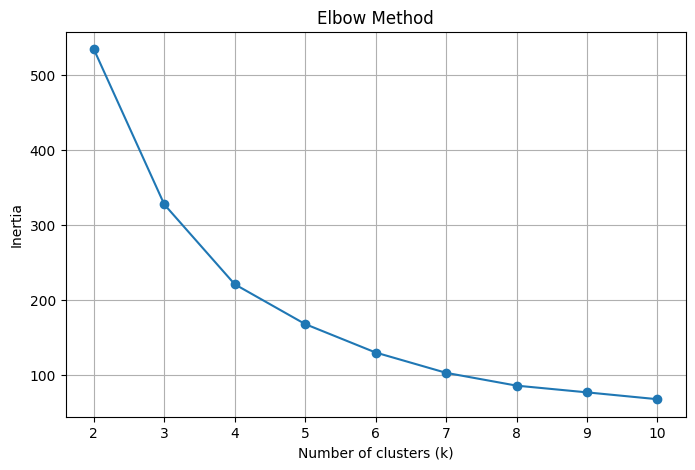

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker='o')

plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.xticks(k_values)
plt.grid(True)

plt.show()

#Наиболее существенное снижение внутрикластерной дисперсии наблюдается при увеличении числа кластеров до k=4

In [23]:
best_k = 4

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(X_cluster_scaled)

print("Cluster counts:")
print(pd.Series(clusters).value_counts().sort_index())

cluster_analysis = (
    train_df.loc[train_df_cleaned.index]
    .assign(cluster=clusters)
    .groupby('cluster')['MEDV']
    .agg(['count', 'mean', 'median'])
    .round(3)
)

print(cluster_analysis)

Cluster counts:
0     57
1    163
2    118
3     19
Name: count, dtype: int64
         count    mean  median
cluster                       
0           57  18.096    15.3
1          163  24.232    21.8
2          118  24.851    23.3
3           19  14.116    11.7


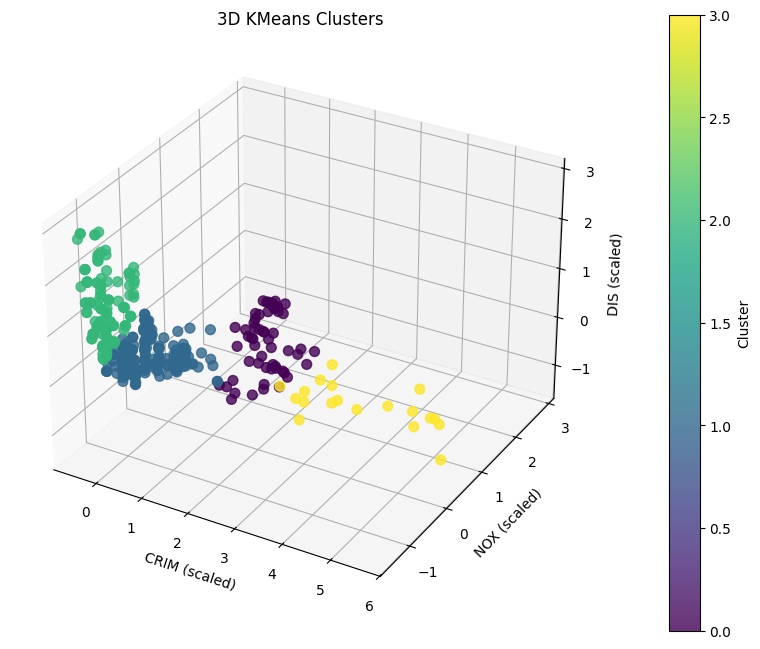

In [24]:
from mpl_toolkits.mplot3d import Axes3D 

fig = plt.figure(figsize=(10, 8))

ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_cluster['CRIM'],
    X_cluster['NOX'],
    X_cluster['DIS'],
    c=clusters,
    cmap='viridis',
    alpha=0.8,
    s=50 
)

ax.set_xlabel('CRIM (scaled)')
ax.set_ylabel('NOX (scaled)')
ax.set_zlabel('DIS (scaled)') 

ax.set_title('3D KMeans Clusters')

fig.colorbar(scatter, ax=ax, label='Cluster', pad=0.1)

plt.show()


In [25]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

features = ['RM', 'LSTAT', 'PTRATIO']

X = df[features]
y = df['MEDV']

model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    model,
    X,
    y,
    cv=kf,
    scoring='r2'
)

print("R² по folds:", np.round(scores, 3))
print("Avg R²:", round(scores.mean(), 3))
print("Std R²:", round(scores.std(), 3))

R² по folds: [0.63  0.666 0.652 0.728 0.644]
Avg R²: 0.664
Std R²: 0.034


In [26]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
import pandas as pd

features = [
    'CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE',
    'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

X = df[features]
y = df['MEDV']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]

results = []

models = {'Linear': LinearRegression()}

for name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=kf,
        scoring={
            'R2': 'r2',
            'MAE': 'neg_mean_absolute_error',
            'RMSE': 'neg_root_mean_squared_error'
        }
    )
    results.append({
        'Model': name,
        'Alpha': 'N/A',
        'Mean R²': scores['test_R2'].mean(),
        'Std R²': scores['test_R2'].std(),
        'Mean MAE': -scores['test_MAE'].mean(),
        'Mean RMSE': -scores['test_RMSE'].mean()
    })

for alpha in alphas:
    alpha_models = {
        'Ridge': make_pipeline(StandardScaler(), Ridge(alpha=alpha)),
        'Lasso': make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=10000))
    }
    
    for name, model in alpha_models.items():
        scores = cross_validate(
            model, X, y, cv=kf,
            scoring={
                'R2': 'r2',
                'MAE': 'neg_mean_absolute_error',
                'RMSE': 'neg_root_mean_squared_error'
            }
        )

        results.append({
            'Model': name,
            'Alpha': alpha,
            'Mean R²': scores['test_R2'].mean(),
            'Std R²': scores['test_R2'].std(),
            'Mean MAE': -scores['test_MAE'].mean(),
            'Mean RMSE': -scores['test_RMSE'].mean()
        })

results_df = pd.DataFrame(results)


print(results_df.round(3))


     Model  Alpha  Mean R²  Std R²  Mean MAE  Mean RMSE
0   Linear    N/A    0.694   0.046     3.470      5.016
1    Ridge  0.001    0.694   0.046     3.470      5.016
2    Lasso  0.001    0.694   0.046     3.469      5.016
3    Ridge   0.01    0.694   0.046     3.470      5.016
4    Lasso   0.01    0.694   0.046     3.461      5.013
5    Ridge    0.1    0.694   0.046     3.469      5.016
6    Lasso    0.1    0.695   0.044     3.437      5.011
7    Ridge    1.0    0.694   0.046     3.466      5.015
8    Lasso    1.0    0.647   0.023     3.751      5.410
9    Ridge   10.0    0.695   0.045     3.439      5.008
10   Lasso   10.0   -0.011   0.007     6.665      9.184
11   Ridge  100.0    0.684   0.035     3.458      5.114
12   Lasso  100.0   -0.011   0.007     6.665      9.184


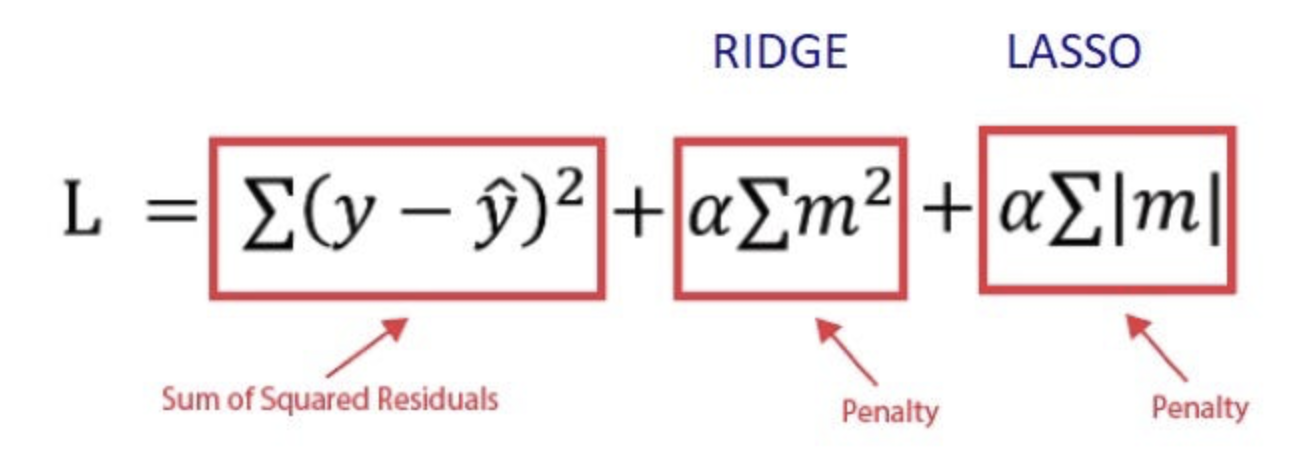

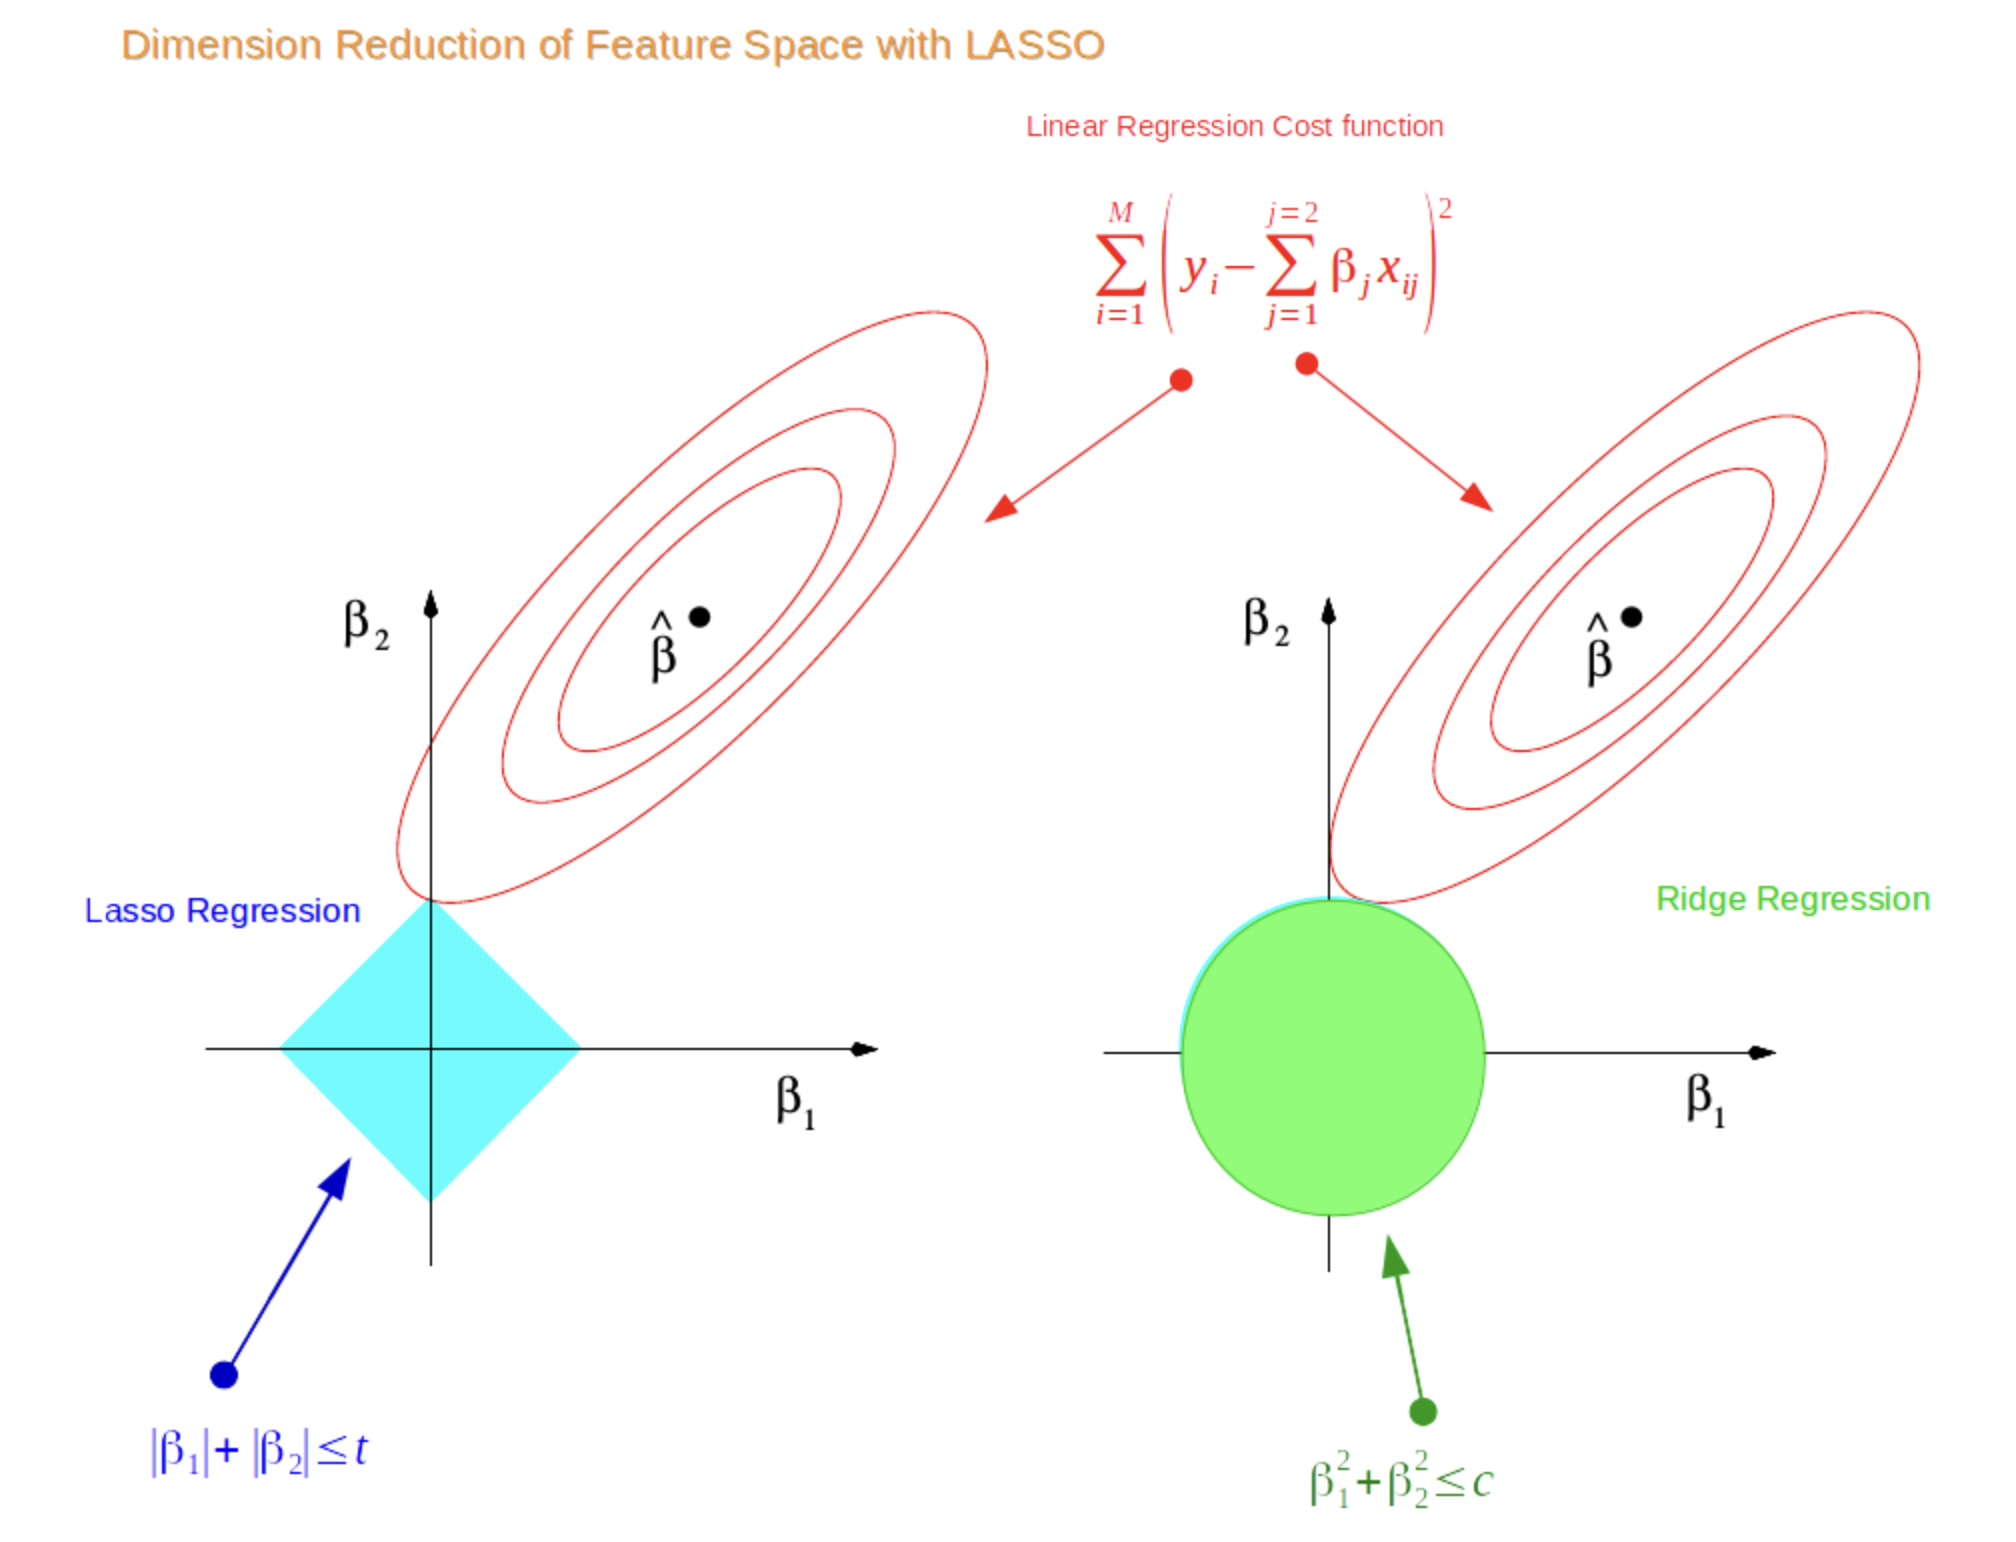

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
import pandas as pd

features = [
    'CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE',
    'DIS', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

X = df[features]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    StandardScaler(),
    LinearRegression()
)

poly_model.fit(X_train, y_train)

y_train_pred = poly_model.predict(X_train)
y_test_pred = poly_model.predict(X_test)

print("Результаты полиномиальной регрессии (степень 2) на обучающей выборке:")
print(f"R²:   {r2_score(y_train, y_train_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_train, y_train_pred):.3f}")
print(f"RMSE: {root_mean_squared_error(y_train, y_train_pred):.3f}")

print("\nРезультаты на тестовой выборке:")
print(f"R²:   {r2_score(y_test, y_test_pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, y_test_pred):.3f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_test_pred):.3f}")

Результаты полиномиальной регрессии (степень 2) на обучающей выборке:
R²:   0.914
MAE:  2.029
RMSE: 2.735

Результаты на тестовой выборке:
R²:   0.807
MAE:  2.652
RMSE: 3.762
